In [ ]:
import os, random, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# These settings are meant to run decently on a laptop CPU.
# For Colab GPU, set fast_run = False and increase epochs.
fast_run = True
epochs = 10 if fast_run else 25
batch_size = 128
learning_rate = 0.003
max_text_chars = 300000 if fast_run else None
max_batches_per_epoch = 400 if fast_run else None
max_val_batches = 120 if fast_run else None

os.makedirs('Results_Problem_2', exist_ok=True)


device: cpu


In [2]:
# Professor style Tiny Shakespeare loader
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
response = requests.get(url)
text = response.text

if max_text_chars is not None:
    text = text[:max_text_chars]

chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
encoded_text = [char_to_int[ch] for ch in text]

print('Text length:', len(text))
print('Vocabulary size:', len(chars))
print('First 500 chars:')
print(text[:500])


Text length: 300000
Vocabulary size: 62
First 500 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
class CharDataset(Dataset):
    def __init__(self, encoded_text, sequence_length):
        self.encoded_text = encoded_text
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.encoded_text) - self.sequence_length

    def __getitem__(self, index):
        seq = self.encoded_text[index:index+self.sequence_length]
        target = self.encoded_text[index+self.sequence_length]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)


def get_loaders(sequence_length):
    dataset = CharDataset(encoded_text, sequence_length)
    train_size = int(len(dataset) * 0.8)
    val_size = len(dataset) - train_size
    gen = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=gen)
    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    val_loader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size)
    return train_loader, val_loader

train_loader, val_loader = get_loaders(20)
print('train batches:', len(train_loader), 'val batches:', len(val_loader))


train batches: 1875 val batches: 469


In [4]:
# LSTM/GRU character model, based on the professor's CharRNN structure.

class ShakespeareModel(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, model_type='LSTM', num_layers=1, fc_size=128, dropout=0.0):
        super(ShakespeareModel, self).__init__()
        self.model_type = model_type
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, hidden_size)

        if model_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        else:
            raise ValueError('model_type must be LSTM or GRU')

        self.fc1 = nn.Linear(hidden_size, fc_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_size, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = output[:, -1, :]
        output = self.fc1(output)
        output = self.relu(output)
        output = self.fc2(output)
        return output


def get_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    return get_params(model) * 4 / (1024 ** 2)


def rough_complexity(model_type, seq_length, hidden_size, num_layers):
    gates = {'GRU': 3, 'LSTM': 4}[model_type]
    return gates * num_layers * seq_length * (hidden_size * hidden_size + hidden_size * hidden_size)


In [5]:
def top_k_accuracy(output, target, k=3):
    _, pred = output.topk(k, dim=1)
    correct = pred.eq(target.view(-1, 1).expand_as(pred))
    return correct.any(dim=1).sum().item()


def evaluate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct1 = 0
    correct3 = 0
    correct5 = 0
    total = 0
    batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct1 += (pred == y).sum().item()
            correct3 += top_k_accuracy(out, y, k=3)
            correct5 += top_k_accuracy(out, y, k=5)
            total += y.size(0)
            batches += 1
            if max_val_batches is not None and batches >= max_val_batches:
                break
    return total_loss / total, correct1 / total, correct3 / total, correct5 / total


def train_model(config):
    print('\nRUNNING:', config)
    train_loader, val_loader = get_loaders(config['seq_length'])
    model = ShakespeareModel(
        vocab_size=len(chars),
        hidden_size=config['hidden_size'],
        model_type=config['model_type'],
        num_layers=config['num_layers'],
        fc_size=config['fc_size'],
        dropout=config.get('dropout', 0.0)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    val_accs = []
    val_top3_accs = []
    val_top5_accs = []
    best_top1 = 0
    best_top3 = 0
    best_top5 = 0
    best_epoch = 0
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        total = 0
        batches = 0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            total += y.size(0)
            batches += 1
            if max_batches_per_epoch is not None and batches >= max_batches_per_epoch:
                break

        train_loss = running_loss / total
        val_loss, val_acc, val_top3, val_top5 = evaluate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_top3_accs.append(val_top3)
        val_top5_accs.append(val_top5)
        if val_top3 > best_top3:
            best_top1 = val_acc
            best_top3 = val_top3
            best_top5 = val_top5
            best_epoch = epoch + 1
        print('epoch', epoch + 1, 'train loss', round(train_loss, 4), 'val loss', round(val_loss, 4), 'top1', round(val_acc, 4), 'top3', round(val_top3, 4))

    training_time = time.time() - start
    final_val_loss = val_losses[-1]
    perplexity = math.exp(final_val_loss) if final_val_loss < 20 else float('inf')

    info = dict(config)
    info.update({
        'epochs': epochs,
        'train_loss': train_losses[-1],
        'val_loss': val_losses[-1],
        'val_accuracy': val_accs[-1],
        'val_top3_accuracy': val_top3_accs[-1],
        'val_top5_accuracy': val_top5_accs[-1],
        'best_val_accuracy': max(val_accs),
        'best_val_top1_at_top3': best_top1,
        'best_val_top3_accuracy': best_top3,
        'best_val_top5_accuracy': best_top5,
        'best_epoch': best_epoch,
        'val_perplexity': perplexity,
        'training_time_sec': training_time,
        'params': get_params(model),
        'model_size_MB': model_size_mb(model),
        'rough_complexity': rough_complexity(config['model_type'], config['seq_length'], config['hidden_size'], config['num_layers'])
    })
    return model, info, train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs


In [6]:
# Required base experiments: LSTM and GRU for sequence lengths 20 and 30.
base_configs = []
for seq_len in [20, 30]:
    base_configs.append({'name': 'base', 'model_type': 'LSTM', 'seq_length': seq_len, 'hidden_size': 128, 'num_layers': 1, 'fc_size': 128, 'dropout': 0.0})
    base_configs.append({'name': 'base', 'model_type': 'GRU', 'seq_length': seq_len, 'hidden_size': 128, 'num_layers': 1, 'fc_size': 128, 'dropout': 0.0})

# Hyperparameter tests: hidden states, layers, and fully connected size.
hyper_configs = [
    {'name': 'small_hidden', 'model_type': 'LSTM', 'seq_length': 20, 'hidden_size': 64, 'num_layers': 1, 'fc_size': 64, 'dropout': 0.0},
    {'name': 'small_hidden', 'model_type': 'GRU', 'seq_length': 20, 'hidden_size': 64, 'num_layers': 1, 'fc_size': 64, 'dropout': 0.0},
    {'name': 'two_layers', 'model_type': 'LSTM', 'seq_length': 20, 'hidden_size': 128, 'num_layers': 2, 'fc_size': 128, 'dropout': 0.2},
    {'name': 'two_layers', 'model_type': 'GRU', 'seq_length': 20, 'hidden_size': 128, 'num_layers': 2, 'fc_size': 128, 'dropout': 0.2},
]

# Extra required sequence length 50.
seq50_configs = [
    {'name': 'seq50', 'model_type': 'LSTM', 'seq_length': 50, 'hidden_size': 128, 'num_layers': 1, 'fc_size': 128, 'dropout': 0.0},
    {'name': 'seq50', 'model_type': 'GRU', 'seq_length': 50, 'hidden_size': 128, 'num_layers': 1, 'fc_size': 128, 'dropout': 0.0},
]

all_configs = base_configs + hyper_configs + seq50_configs
len(all_configs)


10

In [ ]:
all_results = []
history = {}
trained_models = {}

for config in all_configs:
    model, info, train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs = train_model(config)
    key = (config['name'], config['model_type'], config['seq_length'], config['hidden_size'], config['num_layers'], config['fc_size'])
    trained_models[key] = model
    history[key] = (train_losses, val_losses, val_accs, val_top3_accs, val_top5_accs)
    all_results.append(info)

results_df = pd.DataFrame(all_results)
os.makedirs('Results_Problem_2', exist_ok=True)
results_df.to_csv('Results_Problem_2/problem2_results.csv', index=False)
results_df



RUNNING: {'name': 'base', 'model_type': 'LSTM', 'seq_length': 20, 'hidden_size': 128, 'num_layers': 1, 'fc_size': 128, 'dropout': 0.0}
epoch 1 train loss 2.2448 val loss 1.9455 top1 0.432 top3 0.654
epoch 2 train loss 1.8442 val loss 1.8054 top1 0.4699 top3 0.6911
epoch 3 train loss 1.741 val loss 1.7136 top1 0.4943 top3 0.7146
epoch 4 train loss 1.6776 val loss 1.6676 top1 0.5102 top3 0.724
epoch 5 train loss 1.632 val loss 1.6438 top1 0.5135 top3 0.7318
epoch 6 train loss 1.5982 val loss 1.6159 top1 0.516 top3 0.7335
epoch 7 train loss 1.5664 val loss 1.6007 top1 0.5272 top3 0.7348
epoch 8 train loss 1.5448 val loss 1.5912 top1 0.5238 top3 0.7392
epoch 9 train loss 1.5422 val loss 1.5718 top1 0.5277 top3 0.7437
epoch 10 train loss 1.5208 val loss 1.5646 top1 0.5246 top3 0.7467

RUNNING: {'name': 'base', 'model_type': 'GRU', 'seq_length': 20, 'hidden_size': 128, 'num_layers': 1, 'fc_size': 128, 'dropout': 0.0}
epoch 1 train loss 2.2044 val loss 1.9103 top1 0.4428 top3 0.6661
epoch 2 

,name,model_type,seq_length,hidden_size,num_layers,fc_size,dropout,epochs,train_loss,val_loss,...,best_val_accuracy,best_val_top1_at_top3,best_val_top3_accuracy,best_val_top5_accuracy,best_epoch,val_perplexity,training_time_sec,params,model_size_MB,rough_complexity
0,base,LSTM,20,128,1,128,0.0,10,1.520821,1.564615,...,0.527734,0.524609,0.746680,0.833854,10,4.780836,193.367145,164542,0.627678,2621440
1,base,GRU,20,128,1,128,0.0,10,1.541505,1.587946,...,0.526237,0.518750,0.739583,0.824935,7,4.893685,471.892355,131518,0.501701,1966080
2,base,LSTM,30,128,1,128,0.0,10,1.524548,1.580193,...,0.525326,0.525326,0.745052,0.832747,10,4.855894,238.550900,164542,0.627678,3932160
3,base,GRU,30,128,1,128,0.0,10,1.539440,1.611971,...,0.521940,0.516146,0.729622,0.821159,8,5.012681,280.122133,131518,0.501701,2949120
4,small_hidden,LSTM,20,64,1,64,0.0,10,1.622364,1.653899,...,0.510938,0.509831,0.727474,0.820378,10,5.227321,153.924918,45438,0.173332,655360
5,small_hidden,GRU,20,64,1,64,0.0,10,1.628875,1.657070,...,0.509701,0.509701,0.726628,0.815885,10,5.243922,247.968443,37118,0.141594,491520
6,two_layers,LSTM,20,128,2,128,0.2,10,1.584409,1.575533,...,0.524479,0.524479,0.740039,0.828776,10,4.833319,443.620612,296638,1.131584,5242880
7,two_layers,GRU,20,128,2,128,0.2,10,1.632105,1.617493,...,0.515560,0.515560,0.732682,0.823698,10,5.040440,537.522181,230590,0.879631,3932160
8,seq50,LSTM,50,128,1,128,0.0,10,1.527103,1.568025,...,0.522982,0.522982,0.746419,0.834245,10,4.797165,293.132265,164542,0.627678,6553600
9,seq50,GRU,50,128,1,128,0.0,10,1.548965,1.591823,...,0.520247,0.519596,0.736589,0.828711,9,4.912696,318.009172,131518,0.501701,4915200


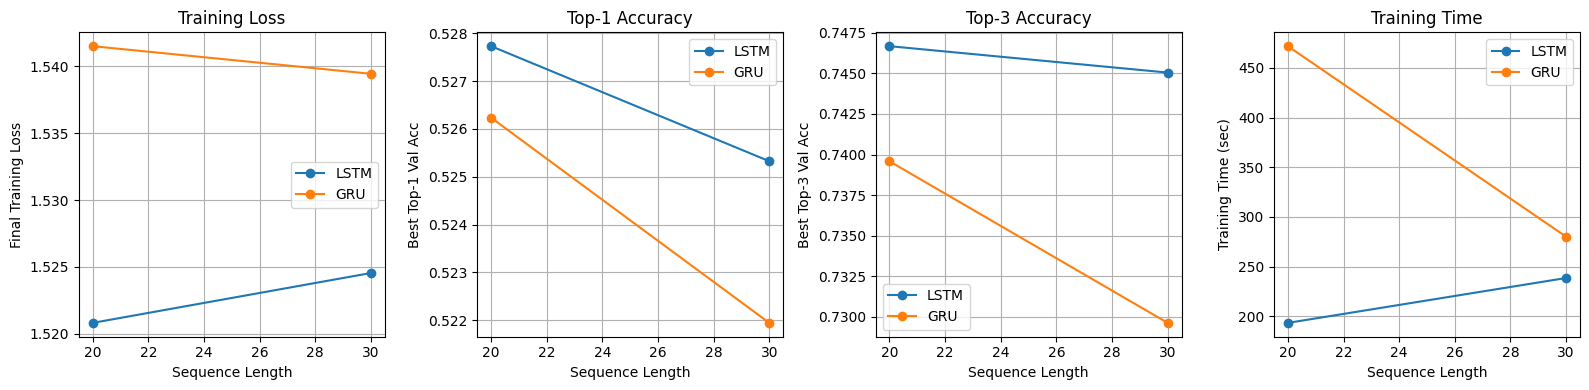

In [ ]:
# Required comparison plots
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
for model_type in ['LSTM', 'GRU']:
    temp = results_df[(results_df['name'] == 'base') & (results_df['model_type'] == model_type)]
    plt.plot(temp['seq_length'], temp['train_loss'], marker='o', label=model_type)
plt.xlabel('Sequence Length')
plt.ylabel('Final Training Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,4,2)
for model_type in ['LSTM', 'GRU']:
    temp = results_df[(results_df['name'] == 'base') & (results_df['model_type'] == model_type)]
    plt.plot(temp['seq_length'], temp['best_val_accuracy'], marker='o', label=model_type)
plt.xlabel('Sequence Length')
plt.ylabel('Best Top-1 Val Acc')
plt.title('Top-1 Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,4,3)
for model_type in ['LSTM', 'GRU']:
    temp = results_df[(results_df['name'] == 'base') & (results_df['model_type'] == model_type)]
    plt.plot(temp['seq_length'], temp['best_val_top3_accuracy'], marker='o', label=model_type)
plt.xlabel('Sequence Length')
plt.ylabel('Best Top-3 Val Acc')
plt.title('Top-3 Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,4,4)
for model_type in ['LSTM', 'GRU']:
    temp = results_df[(results_df['name'] == 'base') & (results_df['model_type'] == model_type)]
    plt.plot(temp['seq_length'], temp['training_time_sec'], marker='o', label=model_type)
plt.xlabel('Sequence Length')
plt.ylabel('Training Time (sec)')
plt.title('Training Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Results_Problem_2/problem2_base_summary_topk.png', dpi=200, bbox_inches='tight')
plt.show()


In [9]:
# Hyperparameter comparison
hyper_df = results_df[results_df['name'].isin(['small_hidden', 'two_layers'])]
hyper_df[['name','model_type','hidden_size','num_layers','fc_size','train_loss','val_loss','best_val_accuracy','best_val_top3_accuracy','best_val_top5_accuracy','val_perplexity','training_time_sec','params','model_size_MB','rough_complexity']]


,name,model_type,hidden_size,num_layers,fc_size,train_loss,val_loss,best_val_accuracy,best_val_top3_accuracy,best_val_top5_accuracy,val_perplexity,training_time_sec,params,model_size_MB,rough_complexity
4,small_hidden,LSTM,64,1,64,1.622364,1.653899,0.510938,0.727474,0.820378,5.227321,153.924918,45438,0.173332,655360
5,small_hidden,GRU,64,1,64,1.628875,1.657070,0.509701,0.726628,0.815885,5.243922,247.968443,37118,0.141594,491520
6,two_layers,LSTM,128,2,128,1.584409,1.575533,0.524479,0.740039,0.828776,4.833319,443.620612,296638,1.131584,5242880
7,two_layers,GRU,128,2,128,1.632105,1.617493,0.515560,0.732682,0.823698,5.040440,537.522181,230590,0.879631,3932160


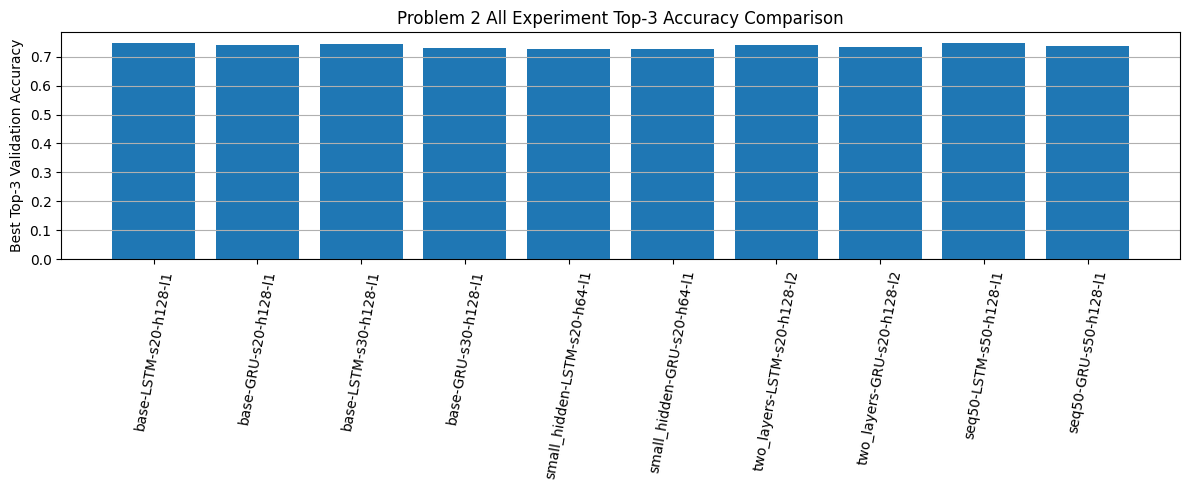

In [ ]:
plt.figure(figsize=(12,5))
labels = results_df['name'] + '-' + results_df['model_type'] + '-s' + results_df['seq_length'].astype(str) + '-h' + results_df['hidden_size'].astype(str) + '-l' + results_df['num_layers'].astype(str)
plt.bar(range(len(results_df)), results_df['best_val_top3_accuracy'])
plt.xticks(range(len(results_df)), labels, rotation=80)
plt.ylabel('Best Top-3 Validation Accuracy')
plt.title('Problem 2 All Experiment Top-3 Accuracy Comparison')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('Results_Problem_2/problem2_all_top3_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()


In [11]:
def generate_text(model, start_text='To be, or not to be', seq_length=30, generate_len=300):
    model.eval()
    generated = start_text
    infer_start = time.time()
    with torch.no_grad():
        for i in range(generate_len):
            current = generated[-seq_length:]
            x = [char_to_int.get(ch, char_to_int[' ']) for ch in current]
            if len(x) < seq_length:
                x = [char_to_int[' ']] * (seq_length - len(x)) + x
            x = torch.tensor(x, dtype=torch.long).unsqueeze(0).to(device)
            out = model(x)
            pred = out.argmax(1).item()
            generated += int_to_char[pred]
    infer_time = time.time() - infer_start
    return generated, infer_time

best_row = results_df.sort_values('best_val_top3_accuracy', ascending=False).iloc[0]
best_key = (best_row['name'], best_row['model_type'], int(best_row['seq_length']), int(best_row['hidden_size']), int(best_row['num_layers']), int(best_row['fc_size']))
best_model = trained_models[best_key]
output_text, inference_time = generate_text(best_model, seq_length=int(best_row['seq_length']))

print('Best model key by top-3 validation accuracy:', best_key)
print('Top-1:', best_row['best_val_accuracy'], 'Top-3:', best_row['best_val_top3_accuracy'], 'Top-5:', best_row['best_val_top5_accuracy'])
print('Inference time for generated text:', inference_time)
print(output_text)


Best model key by top-3 validation accuracy: ('base', 'LSTM', 20, 128, 1, 128)
Top-1: 0.527734375 Top-3: 0.7466796875 Top-5: 0.8338541666666667
Inference time for generated text: 0.2351517677307129
To be, or not to be the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come, the come,


In [ ]:
# Add inference time and output sequence for each saved model.
generated_rows = []
for key, model in trained_models.items():
    out_text, inf_time = generate_text(model, seq_length=key[2], generate_len=200)
    generated_rows.append({'key': str(key), 'inference_time_sec': inf_time, 'output_sequence': out_text})

generated_df = pd.DataFrame(generated_rows)
generated_df.to_csv('Results_Problem_2/problem2_generated_outputs.csv', index=False)
generated_df


,key,inference_time_sec,output_sequence
0,"('base', 'LSTM', 20, 128, 1, 128)",0.127528,"To be, or not to be the come, the come, the co..."
1,"('base', 'GRU', 20, 128, 1, 128)",0.256887,"To be, or not to be sonest the see the senator..."
2,"('base', 'LSTM', 30, 128, 1, 128)",0.144914,"To be, or not to be the show the shall the com..."
3,"('base', 'GRU', 30, 128, 1, 128)",0.307477,"To be, or not to be the stood the stroke the s..."
4,"('small_hidden', 'LSTM', 20, 64, 1, 64)",0.083169,"To be, or not to be the comes the comes the co..."
5,"('small_hidden', 'GRU', 20, 64, 1, 64)",0.216240,"To be, or not to be to the procest the procean..."
6,"('two_layers', 'LSTM', 20, 128, 2, 128)",0.167092,"To be, or not to be the proness the proness th..."
7,"('two_layers', 'GRU', 20, 128, 2, 128)",0.444054,"To be, or not to be to the see the see the see..."
8,"('seq50', 'LSTM', 50, 128, 1, 128)",0.175868,"To be, or not to be be be be be be be be be be..."
9,"('seq50', 'GRU', 50, 128, 1, 128)",0.531299,"To be, or not to be the grace the grace the gr..."
